In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/amex-default-prediction-small/sample_submission.csv
/kaggle/input/competitions/amex-default-prediction-small/train.csv
/kaggle/input/competitions/amex-default-prediction-small/test.csv


In [2]:
import os

print(os.listdir("/kaggle/input/competitions"))

['amex-default-prediction-small']


In [3]:
DATA_PATH = "/kaggle/input/competitions/amex-default-prediction-small/"

print(os.listdir(DATA_PATH))

['sample_submission.csv', 'train.csv', 'test.csv']


In [4]:
import pandas as pd

train = pd.read_csv(DATA_PATH + "train.csv")

print(train.shape)
print(train.columns.tolist())
train.head()

(7000, 191)
['customer_ID', 'S_2', 'P_2', 'D_39', 'B_1', 'B_2', 'R_1', 'S_3', 'D_41', 'B_3', 'D_42', 'D_43', 'D_44', 'B_4', 'D_45', 'B_5', 'R_2', 'D_46', 'D_47', 'D_48', 'D_49', 'B_6', 'B_7', 'B_8', 'D_50', 'D_51', 'B_9', 'R_3', 'D_52', 'P_3', 'B_10', 'D_53', 'S_5', 'B_11', 'S_6', 'D_54', 'R_4', 'S_7', 'B_12', 'S_8', 'D_55', 'D_56', 'B_13', 'R_5', 'D_58', 'S_9', 'B_14', 'D_59', 'D_60', 'D_61', 'B_15', 'S_11', 'D_62', 'D_63', 'D_64', 'D_65', 'B_16', 'B_17', 'B_18', 'B_19', 'D_66', 'B_20', 'D_68', 'S_12', 'R_6', 'S_13', 'B_21', 'D_69', 'B_22', 'D_70', 'D_71', 'D_72', 'S_15', 'B_23', 'D_73', 'P_4', 'D_74', 'D_75', 'D_76', 'B_24', 'R_7', 'D_77', 'B_25', 'B_26', 'D_78', 'D_79', 'R_8', 'R_9', 'S_16', 'D_80', 'R_10', 'R_11', 'B_27', 'D_81', 'D_82', 'S_17', 'R_12', 'B_28', 'R_13', 'D_83', 'R_14', 'R_15', 'D_84', 'R_16', 'B_29', 'B_30', 'S_18', 'D_86', 'D_87', 'R_17', 'R_18', 'D_88', 'B_31', 'S_19', 'R_19', 'B_32', 'S_20', 'R_20', 'R_21', 'B_33', 'D_89', 'R_22', 'R_23', 'D_91', 'D_92', 'D_93', 

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,00ce1be3ce9db3f093faaac602837c7169cac86a5d1a2d...,2017-03-18,0.560250,0.033275,0.065029,0.156973,0.009881,NaN,0.008204,0.123275,...,NaN,NaN,0.000513,0.002914,0.008421,NaN,0.003774,0.002979,0.004032,0
1,0649f5e4f57164bddca6b3508c03749b0a850bbf362488...,2017-03-03,0.487026,0.206390,0.172201,0.063273,0.009864,0.192295,0.009795,0.139360,...,NaN,NaN,0.006648,0.009368,0.004387,NaN,0.005004,0.000874,0.008043,1
2,023d8c3e7ba0b97fdd9dd33db3c4c5c87e1cab9fd64b23...,2017-03-20,0.708663,0.002014,0.003317,0.818072,0.005209,NaN,0.001108,0.001880,...,NaN,NaN,0.005511,0.005931,0.000564,NaN,0.002715,0.002846,0.006002,0
3,02e8e7c84fef103f7049edec2b503c393a1f2d19deb08b...,2017-03-25,0.563401,0.001283,0.672645,0.055807,1.253864,0.161688,0.189719,0.677310,...,NaN,NaN,0.006273,0.001105,0.005410,NaN,0.008415,0.001129,0.008275,1
4,069806e452503a9e44c4875a9cef3c29bd470b03cf9ef3...,2018-03-28,0.402692,0.096667,0.286624,0.817046,0.002066,0.171350,0.004585,0.001749,...,NaN,NaN,NaN,0.003678,NaN,NaN,NaN,0.001063,NaN,0


In [5]:
# ============================================================
# Credit Risk Default Prediction
# Notebook 1 - Data Understanding
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
train = pd.read_csv(DATA_PATH + "train.csv")

print("Shape:", train.shape)

train.head()

Shape: (7000, 191)


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,D_66,B_20,D_68,S_12,R_6,S_13,B_21,D_69,B_22,D_70,D_71,D_72,S_15,B_23,D_73,P_4,D_74,D_75,D_76,B_24,R_7,D_77,B_25,B_26,D_78,D_79,R_8,R_9,S_16,D_80,R_10,R_11,B_27,D_81,D_82,S_17,R_12,B_28,R_13,D_83,R_14,R_15,D_84,R_16,B_29,B_30,S_18,D_86,D_87,R_17,R_18,D_88,B_31,S_19,R_19,B_32,S_20,R_20,R_21,B_33,D_89,R_22,R_23,D_91,D_92,D_93,D_94,R_24,R_25,D_96,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,00ce1be3ce9db3f093faaac602837c7169cac86a5d1a2d...,2017-03-18,0.560250,0.033275,0.065029,0.156973,0.009881,NaN,0.008204,0.123275,NaN,0.007914,0.125089,0.346408,0.313012,0.009918,0.009521,0.505127,0.607742,0.167647,NaN,0.023286,0.239207,0.005956,0.033728,0.006847,0.029595,0.004609,0.141589,0.672130,0.050204,0.005170,0.007568,0.037337,1.009173,1.001949,0.002685,NaN,0.010114,0.002943,0.187930,0.038321,0.003193,0.002160,0.356085,NaN,0.020335,0.271761,0.053919,0.732626,0.000175,0.283419,0.178927,CO,O,0.005000,0.837417,0.740663,0.183680,0.086594,NaN,0.362803,6.0,0.193970,0.002370,0.009762,0.000334,0.009644,0.005173,0.252625,0.012543,0.000076,0.504321,0.212150,NaN,0.003871,0.148796,0.203906,NaN,0.004074,0.009610,0.169353,0.027570,0.003557,0.001014,0.003042,0.001417,NaN,0.008613,0.204979,0.008804,0.007762,0.009707,0.002811,NaN,0.000811,1.009542,0.117433,0.004905,0.008814,0.003621,0.009550,0.002792,0.007707,NaN,0.0,0.006801,0.006182,NaN,0.003328,0.002490,NaN,1,0.004750,0.007920,1.006229,0.002509,0.005968,0.001502,0.000094,0.007197,0.000052,0.003157,0.003291,0.000063,0.008480,0.004701,0.007622,0.005221,0.009287,0.295282,0.134178,0.084336,0.974502,0.004701,0.000593,0.002047,0.001880,NaN,NaN,0.009126,0.002125,0.064665,0.003107,0.031752,4.0,NaN,0.006778,NaN,NaN,NaN,1.009891,0.220301,NaN,0.007602,1.0,0.236796,0.0,-1.0,0.642800,0.641934,0.0,0.785815,0.429252,0.000233,0.187802,0.001518,1.0,0.002288,1.008437,1.005432,0.007537,NaN,0.005965,0.001741,NaN,0.005785,0.001270,NaN,NaN,NaN,NaN,NaN,0.000513,0.002914,0.008421,NaN,0.003774,0.002979,0.004032,0
1,0649f5e4f57164bddca6b3508c03749b0a850bbf362488...,2017-03-03,0.487026,0.206390,0.172201,0.063273,0.009864,0.192295,0.009795,0.139360,0.091855,NaN,0.009143,0.273542,0.025246,0.005022,0.001971,0.449637,0.167139,0.448105,NaN,0.019403,0.331718,1.008436,NaN,0.001402,0.501922,0.001606,0.050119,0.655542,0.022632,NaN,0.925091,0.128985,0.005001,1.000173,0.005924,0.363165,0.015549,0.169170,0.337102,NaN,0.021342,0.006076,0.638607,NaN,0.040785,0.277242,0.176756,0.328728,0.000728,0.206521,0.007811,CO,O,0.005685,0.584089,1.007681,0.186494,0.005273,NaN,0.419345,6.0,0.191817,0.000614,0.426756,0.009835,0.005511,0.005692,0.506909,0.005921,0.000343,0.501418,0.287889,NaN,0.944988,0.652034,0.667215,NaN,0.002895,0.000469,NaN,0.068037,0.006780,0.008434,0.001739,0.004252,NaN,0.009443,0.200662,0.000115,0.000136,0.008091,0.008576,NaN,0.002768,1.009143,0.110516,0.000273,0.007195,0.004457,0.007648,0.002856,0.009962,NaN,0.0,0.008534,0.009159,NaN,0.004610,0.008816,NaN,1,0.008617,0.005811,0.003440,0.007637,0.007242,0.007981,0.002977,0.002386,0.007610,0.000123,0.001175,0.001411,0.008400,0.002963,0.009912,0.001796,0.006142,0.997454,0.136773,0.997941,0.978709,0.000590,0.000631,0.000315,0.001303,NaN,NaN,0.004987,0.008316,0.172905,NaN,1.003704,4.0,NaN,0.002681,NaN,NaN,NaN,1.007067,0.203503,0.004612,0.001532,0.0,0.216147,0.0,2.0,0.221121,0.218022,0.0,0.241029,0.147222,0.008857,0.142040,0.006438,0.0,0.006679,0.005490,0.001863,0.009207,NaN,0.000805,0.006130,NaN,0.000284,0.0

In [7]:
# Dataset information
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Columns: 191 entries, customer_ID to target
dtypes: float64(185), int64(2), object(4)
memory usage: 10.2+ MB


In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
P_2,6739.0,0.659056,0.227957,-2.657569e-01,0.485254,0.678967,0.857862,1.009885
D_39,7000.0,0.121195,0.232483,1.078048e-06,0.003708,0.007427,0.151850,4.094725
B_1,7000.0,0.110040,0.198050,-2.688446e-02,0.008407,0.027267,0.109068,1.324053
B_2,6975.0,0.658303,0.373870,2.461921e-05,0.232559,0.814814,1.001436,1.009990
R_1,7000.0,0.055982,0.177607,8.755637e-08,0.002811,0.005683,0.008287,2.255852
...,...,...,...,...,...,...,...,...
D_142,1075.0,0.392486,0.235434,-2.049514e-03,0.204288,0.391759,0.551923,1.428317
D_143,6257.0,0.176864,0.377196,1.497274e-07,0.003159,0.006170,0.009094,1.009990
D_144,6537.0,0.053367,0.186558,6.975402e-06,0.002745,0.005497,0.008319,1.342357
D_145,6257.0,0.061788,0.184669,4.244097e-08,0.003093,0.006090,0.009055,2.183611


In [9]:
missing = train.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

print(f"Columns with missing values: {len(missing)}")

missing.head(20)

Columns with missing values: 115


D_87     6995
D_88     6993
D_110    6978
B_39     6978
D_111    6978
D_108    6966
B_42     6918
D_73     6885
D_138    6795
D_136    6795
D_135    6795
D_134    6795
D_137    6795
R_9      6586
B_29     6482
D_106    6415
D_49     6414
D_132    6414
D_66     6360
R_26     6281
dtype: int64

In [10]:
duplicates = train.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [11]:
# Display data types
train.dtypes.value_counts()


float64    185
object       4
int64        2
Name: count, dtype: int64

In [12]:
# List all object columns
object_columns = train.select_dtypes(include="object").columns

print("Object Columns:")
print(object_columns.tolist())

Object Columns:
['customer_ID', 'S_2', 'D_63', 'D_64']


In [13]:
# Count target values
train["target"].value_counts()

target
0    5156
1    1844
Name: count, dtype: int64

In [14]:
# Percentage distribution
train["target"].value_counts(normalize=True) * 100

target
0    73.657143
1    26.342857
Name: proportion, dtype: float64

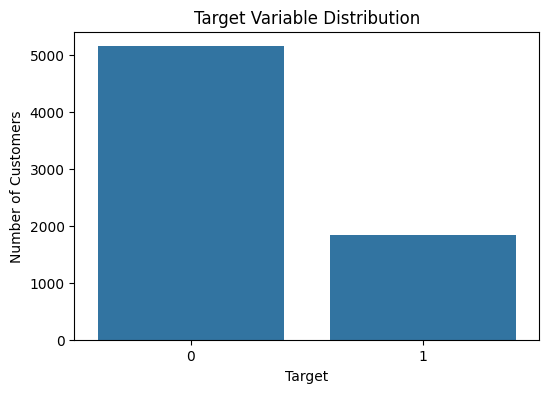

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=train)

plt.title("Target Variable Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
# Missing value count and percentage
missing_df = pd.DataFrame({
    "missing_count": train.isnull().sum(),
    "missing_percentage": (train.isnull().sum() / len(train)) * 100
})

missing_df = missing_df[missing_df["missing_count"] > 0]
missing_df = missing_df.sort_values(by="missing_percentage", ascending=False)

print("Number of columns with missing values:", missing_df.shape[0])

missing_df.head(20)

Number of columns with missing values: 115


,missing_count,missing_percentage
D_87,6995,99.928571
D_88,6993,99.900000
B_39,6978,99.685714
D_110,6978,99.685714
D_111,6978,99.685714
D_108,6966,99.514286
B_42,6918,98.828571
D_73,6885,98.357143
D_135,6795,97.071429
D_136,6795,97.071429


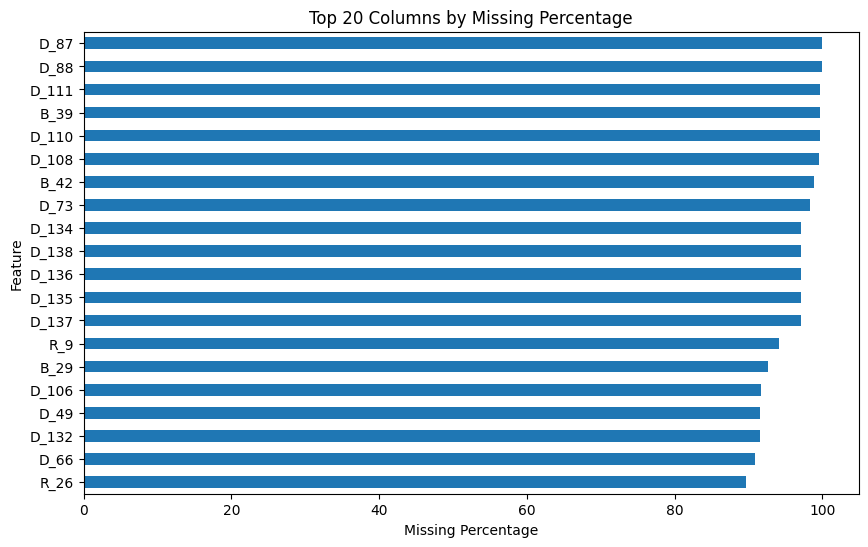

In [17]:
plt.figure(figsize=(10,6))

missing_df.head(20)["missing_percentage"].sort_values().plot(kind="barh")

plt.title("Top 20 Columns by Missing Percentage")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")

plt.show()

In [18]:
high_missing_cols = missing_df[missing_df["missing_percentage"] > 50].index.tolist()

print("Columns with more than 50% missing values:", len(high_missing_cols))
print(high_missing_cols)

Columns with more than 50% missing values: 30
['D_87', 'D_88', 'B_39', 'D_110', 'D_111', 'D_108', 'B_42', 'D_73', 'D_135', 'D_136', 'D_138', 'D_134', 'D_137', 'R_9', 'B_29', 'D_106', 'D_132', 'D_49', 'D_66', 'R_26', 'D_76', 'D_142', 'D_53', 'D_42', 'D_82', 'B_17', 'D_56', 'D_50', 'D_105', 'S_9']


In [19]:
# Create a copy of the original data
df = train.copy()

# Drop columns with more than 50% missing values
df.drop(columns=high_missing_cols, inplace=True)

print("Shape after dropping high-missing columns:", df.shape)

Shape after dropping high-missing columns: (7000, 161)


notebook 2
Data cleaning and Preprocessing

In [20]:
# Rebuild clean feature matrix from df
X = df.drop(columns=["customer_ID", "target"]).copy()
y = df["target"].copy()

# Convert S_2 to proper datetime BEFORE encoding
X["S_2"] = pd.to_datetime(X["S_2"])

# Create date features
date_features = pd.DataFrame({
    "statement_year": X["S_2"].dt.year,
    "statement_month": X["S_2"].dt.month,
    "statement_quarter": X["S_2"].dt.quarter
}, index=X.index)

# Drop original date and add engineered date features
X = X.drop(columns=["S_2"])
X = pd.concat([X, date_features], axis=1)

# Identify columns again
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

# Fill numeric missing values with median
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Encode only remaining categorical columns: D_63, D_64
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Final checks
print("Final X shape:", X.shape)
print("Remaining missing values:", X.isnull().sum().sum())
print("Data types:")
print(X.dtypes.value_counts())
print("Remaining object columns:", X.select_dtypes(include="object").columns.tolist())

Final X shape: (7000, 161)
Remaining missing values: 0
Data types:
float64    155
int64        3
int32        3
Name: count, dtype: int64
Remaining object columns: []


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training Features: (5600, 161)
Testing Features : (1400, 161)
Training Target  : (5600,)
Testing Target   : (1400,)

Train target distribution:
target
0    73.660714
1    26.339286
Name: proportion, dtype: float64

Test target distribution:
target
0    73.642857
1    26.357143
Name: proportion, dtype: float64


Notebook 3- baseline xgboost model

In [22]:
from xgboost import XGBClassifier

In [23]:
# Create baseline XGBoost model

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42

)
xgb_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [24]:
y_pred_proba = xgb_model.predict_proba(X_test)

print(y_pred_proba.shape)

y_pred_proba[:5]

(1400, 2)


array([[9.9887222e-01, 1.1277555e-03],
       [3.2852292e-02, 9.6714771e-01],
       [9.9998605e-01, 1.3944422e-05],
       [9.9346793e-01, 6.5320786e-03],
       [4.4615090e-02, 9.5538491e-01]], dtype=float32)

In [25]:
pd_scores = y_pred_proba[:, 1]

pd_scores[:10]

array([1.1277555e-03, 9.6714771e-01, 1.3944422e-05, 6.5320786e-03,
       9.5538491e-01, 7.1117334e-02, 7.7824116e-05, 3.9234685e-04,
       8.2811165e-01, 1.3580214e-03], dtype=float32)

In [26]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, pd_scores)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.8969


In [27]:
# Convert probabilities into predictions

y_pred = (pd_scores >= 0.5).astype(int)

print(y_pred[:20])

[0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0]


Confusion Matrix:
[[912 119]
 [132 237]]


<Figure size 600x600 with 0 Axes>

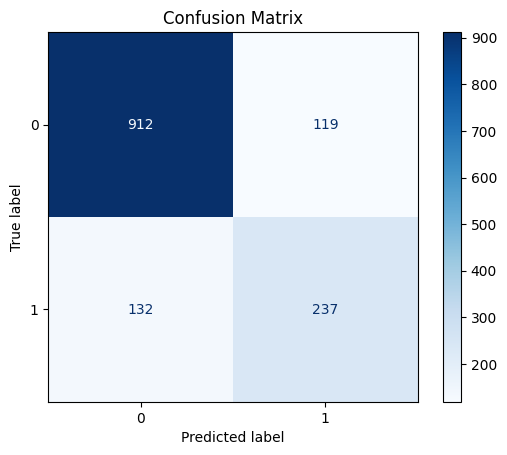

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [29]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred),4))
print("Recall   :", round(recall_score(y_test, y_pred),4))
print("F1 Score :", round(f1_score(y_test, y_pred),4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.8207
Precision: 0.6657
Recall   : 0.6423
F1 Score : 0.6538

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1031
           1       0.67      0.64      0.65       369

    accuracy                           0.82      1400
   macro avg       0.77      0.76      0.77      1400
weighted avg       0.82      0.82      0.82      1400



In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import pandas as pd

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    y_pred = (pd_scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "Threshold": threshold,
        "Accuracy": round(accuracy_score(y_test, y_pred),4),
        "Precision": round(precision_score(y_test, y_pred),4),
        "Recall": round(recall_score(y_test, y_pred),4),
        "F1 Score": round(f1_score(y_test, y_pred),4),
        "True Positive": tp,
        "False Positive": fp,
        "True Negative": tn,
        "False Negative": fn
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score,True Positive,False Positive,True Negative,False Negative
0,0.3,0.8250,0.6455,0.7453,0.6918,275,151,880,94
1,0.4,0.8186,0.6456,0.6911,0.6675,255,140,891,114
2,0.5,0.8207,0.6657,0.6423,0.6538,237,119,912,132
3,0.6,0.8250,0.6937,0.6016,0.6444,222,98,933,147
4,0.7,0.8207,0.7092,0.5420,0.6144,200,82,949,169


In [31]:
import pandas as pd

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,P_2,0.157352
5,S_3,0.023375
64,P_4,0.020203
16,D_48,0.019366
125,B_38,0.017161
11,D_45,0.015451
7,B_3,0.012927
33,S_8,0.012404
21,B_9,0.011003
46,D_64,0.010784


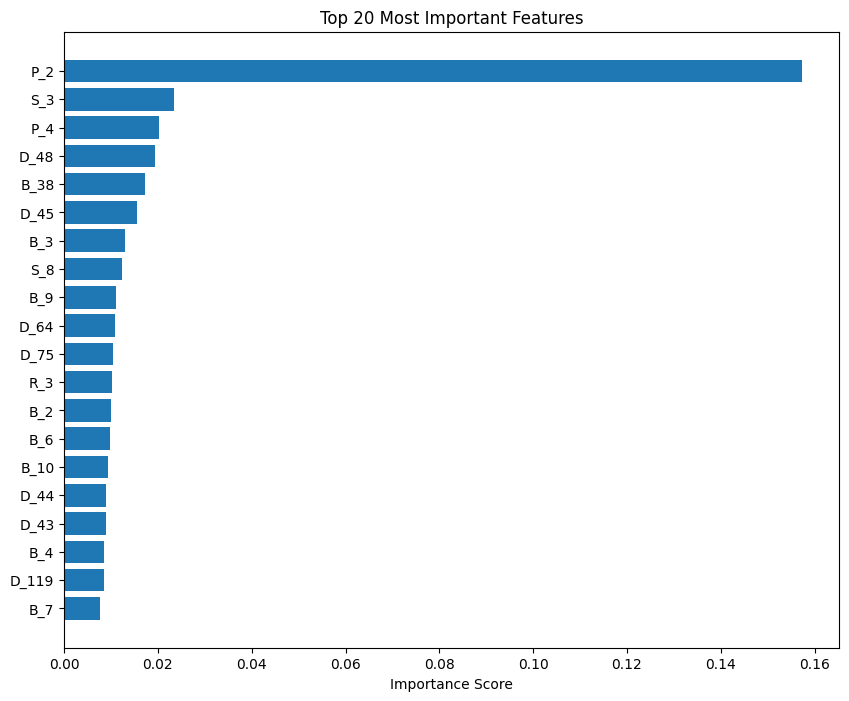

In [32]:
import matplotlib.pyplot as plt

top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20["Feature"], top20["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")

plt.xlabel("Importance Score")

plt.show()

In [33]:
import shap

print(shap.__version__)

0.51.0


In [34]:
explainer = shap.TreeExplainer(xgb_model)

print("SHAP Explainer Created Successfully!")

SHAP Explainer Created Successfully!


In [35]:
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1400, 161)


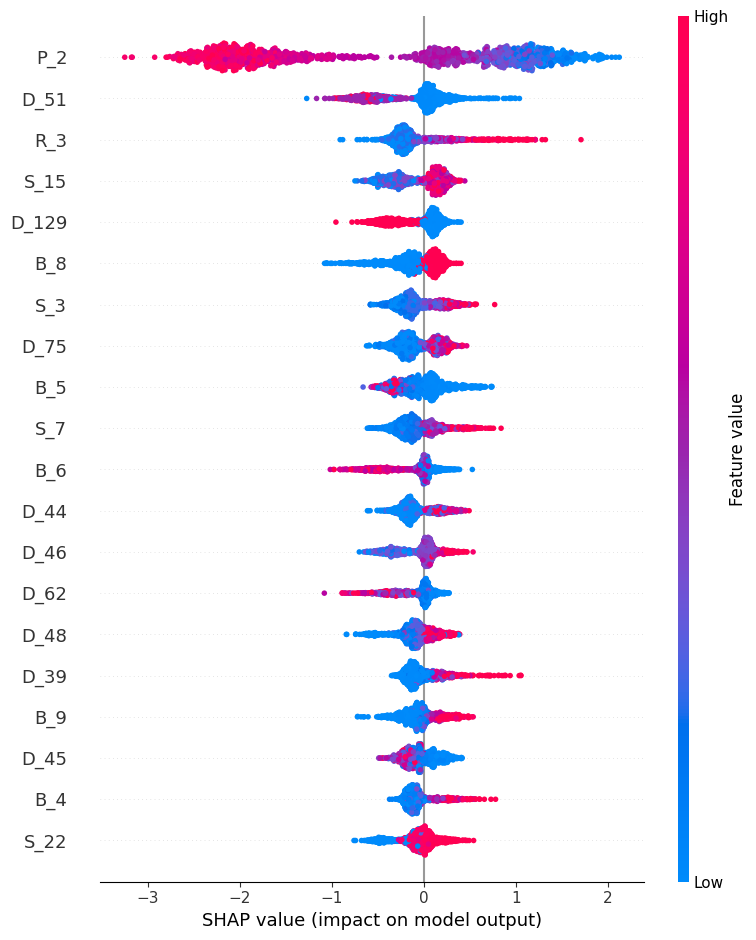

In [36]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

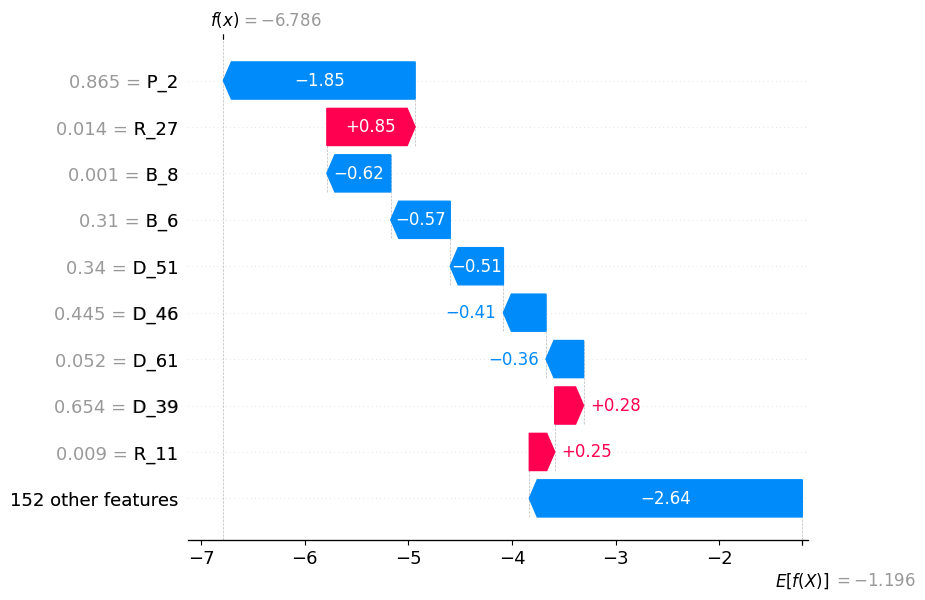

In [37]:
customer = 0

shap.plots.waterfall(
    explainer(X_test.iloc[[customer]])[0]
)

In [38]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'max_depth': [3,5,7],
    'learning_rate': [0.05,0.1],
    'n_estimators': [100,200],
    'subsample': [0.8,1.0],
    'colsample_bytree': [0.8,1.0]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC:")
print(grid_search.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Best ROC-AUC:
0.9000064556949958
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1.0; total time=   2.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=   3.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.8; total time=   4.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=1.0; total time=   4.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=200, subsample=1.0; total time=   7.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=100, subsam

In [39]:
threshold = 0.40

business_df = pd.DataFrame({
    "Actual_Default": y_test.values,
    "PD": pd_scores
})

business_df["Decision"] = business_df["PD"].apply(
    lambda x: "Approve" if x < threshold else "Decline"
)

business_df.head()

,Actual_Default,PD,Decision
0,0,0.001128,Approve
1,0,0.967148,Decline
2,0,0.000014,Approve
3,0,0.006532,Approve
4,0,0.955385,Decline


In [40]:
approval_rate = (business_df["Decision"]=="Approve").mean()*100

rejection_rate = (business_df["Decision"]=="Decline").mean()*100

print(f"Approval Rate : {approval_rate:.2f}%")
print(f"Rejection Rate: {rejection_rate:.2f}%")

Approval Rate : 71.79%
Rejection Rate: 28.21%


In [41]:
approved = business_df[business_df["Decision"]=="Approve"]

portfolio_default_rate = approved["Actual_Default"].mean()*100

print(f"Portfolio Default Rate: {portfolio_default_rate:.2f}%")

Portfolio Default Rate: 11.34%


In [42]:
import pandas as pd

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    business_df = pd.DataFrame({
        "Actual_Default": y_test.values,
        "PD": pd_scores
    })

    business_df["Decision"] = business_df["PD"].apply(
        lambda x: "Approve" if x < threshold else "Decline"
    )

    approval_rate = (
        business_df["Decision"] == "Approve"
    ).mean() * 100

    rejection_rate = (
        business_df["Decision"] == "Decline"
    ).mean() * 100

    approved = business_df[
        business_df["Decision"] == "Approve"
    ]

    portfolio_default_rate = (
        approved["Actual_Default"].mean() * 100
    )

    declined = business_df[
        business_df["Decision"] == "Decline"
    ]

    captured_defaults = declined["Actual_Default"].sum()

    total_defaults = business_df["Actual_Default"].sum()

    default_capture_rate = (
        captured_defaults / total_defaults
    ) * 100

    results.append({
        "Threshold": threshold,
        "Approval Rate (%)": round(approval_rate,2),
        "Rejection Rate (%)": round(rejection_rate,2),
        "Portfolio Default Rate (%)": round(portfolio_default_rate,2),
        "Default Capture Rate (%)": round(default_capture_rate,2)
    })

business_summary = pd.DataFrame(results)

business_summary

,Threshold,Approval Rate (%),Rejection Rate (%),Portfolio Default Rate (%),Default Capture Rate (%)
0,0.3,69.57,30.43,9.65,74.53
1,0.4,71.79,28.21,11.34,69.11
2,0.5,74.57,25.43,12.64,64.23
3,0.6,77.14,22.86,13.61,60.16
4,0.7,79.86,20.14,15.12,54.20
